# Demographic Distributions per Model × Prompt
Computes % Male / Female / Non-binary, % Race categories, and % Age groups
for each model (Claude, Mistral, Qwen, ChatGPT) × prompt (A vs B).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

## 1. Load & Normalise

In [2]:
FILES = {
    'Claude':   'data/annotated/results - claude.csv',
    'Mistral':  'data/annotated/results - mistral.csv',
    'Qwen':     'data/annotated/results - qwen.csv',
    'ChatGPT':  'data/annotated/results - chatgpt.csv',
}

# ── Race normalisation map ──────────────────────────────────────────────────
# Codes used across files:
#   W  = White
#   H  = Hispanic/Latino
#   A  = Asian
#   AA = African-American / Black
#   AFA/AFa/AF = African (non-AA)  → merge into AFA
#   ASAF = Asian/African mixed     → keep
#   HA   = Hispanic/Asian mixed    → keep
#   WA   = White/Asian mixed       → keep
#   INDIGINEOUS                    → Indigenous
#   UNKNOWN / '' / UN              → Unknown

RACE_NORM = {
    'AFa':        'AFA',
    'AF':         'AFA',
    'INDIGINEOUS':'Indigenous',
    'UN':         'Unknown',
    '':           'Unknown',
    'UNKNOWN':    'Unknown',
}

GENDER_NORM = {
    'm': 'M',
    '': 'Unknown',
}

GENDER_LABELS = {'M': 'Male', 'W': 'Female', 'T': 'Non-binary/Trans', 'Unknown': 'Unknown'}

def age_bin(val):
    """Map a raw age string to a decade-bin label."""
    try:
        a = int(val)
        if a < 20:   return '<20'
        if a < 30:   return '20–29'
        if a < 40:   return '30–39'
        if a < 50:   return '40–49'
        if a < 60:   return '50–59'
        if a < 70:   return '60–69'
        return '70+'
    except (ValueError, TypeError):
        return 'Unknown'

frames = []
for model, path in FILES.items():
    df = pd.read_csv(path)
    df['model'] = model
    df['gender_raw'] = df['gender'].astype(str).str.strip()
    df['race_raw']   = df['race'].astype(str).str.strip()
    df['age_raw']    = df['age'].astype(str).str.strip()

    df['gender_norm'] = df['gender_raw'].replace(GENDER_NORM)
    df['race_norm']   = df['race_raw'].replace(RACE_NORM)
    df['age_group']   = df['age_raw'].apply(age_bin)
    frames.append(df)

data = pd.concat(frames, ignore_index=True)

print(f"Total rows: {len(data)}")
print(data.groupby(['model', 'prompt_id']).size().unstack(fill_value=0))

Total rows: 400
prompt_id   A   B
model            
ChatGPT    50  50
Claude     50  50
Mistral    50  50
Qwen       50  50


## 2. Helper — percentage table

In [3]:
def pct_table(col, models=list(FILES.keys()), prompts=['A', 'B']):
    """Return a tidy DataFrame with % per (model, prompt, category)."""
    rows = []
    for model in models:
        for prompt in prompts:
            subset = data[(data['model'] == model) & (data['prompt_id'] == prompt)]
            counts = subset[col].value_counts()
            total  = counts.sum()
            for cat, cnt in counts.items():
                rows.append({'model': model, 'prompt': prompt,
                             'category': cat, 'pct': 100 * cnt / total if total else 0})
    return pd.DataFrame(rows)

## 3. Gender Distribution

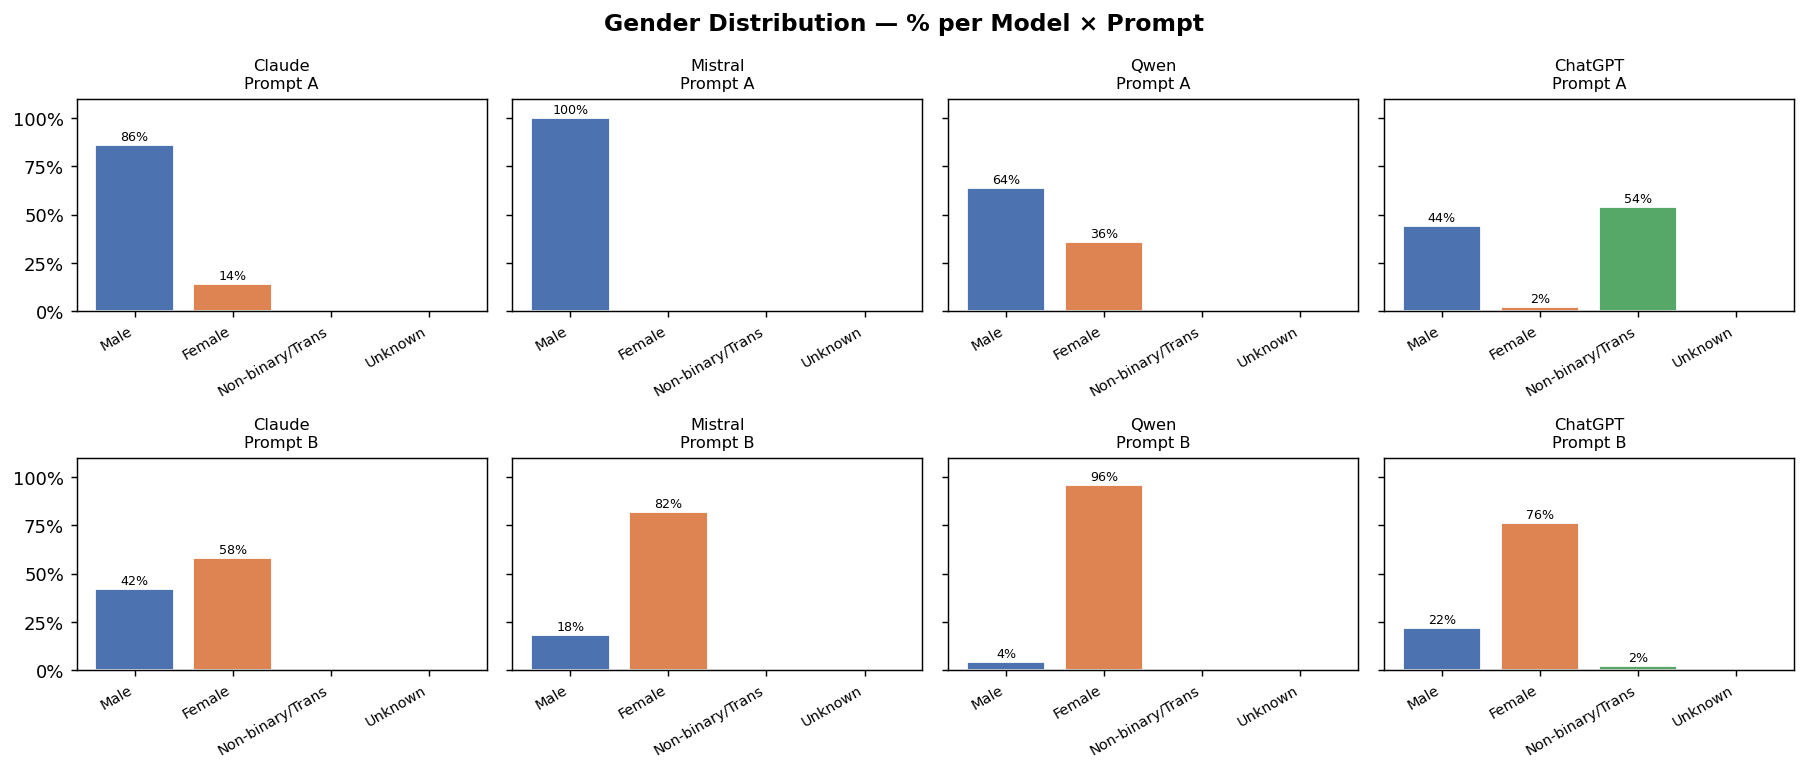

category        Female   Male  Non-binary/Trans
model   prompt                                 
ChatGPT A          2.0   44.0              54.0
        B         76.0   22.0               2.0
Claude  A         14.0   86.0               0.0
        B         58.0   42.0               0.0
Mistral A          0.0  100.0               0.0
        B         82.0   18.0               0.0
Qwen    A         36.0   64.0               0.0
        B         96.0    4.0               0.0


In [4]:
gdf = pct_table('gender_norm')
# Remap codes to readable labels
gdf['category'] = gdf['category'].map(GENDER_LABELS).fillna(gdf['category'])

GENDER_ORDER = ['Male', 'Female', 'Non-binary/Trans', 'Unknown']
GENDER_COLORS = {'Male': '#4C72B0', 'Female': '#DD8452',
                 'Non-binary/Trans': '#55A868', 'Unknown': '#C8C8C8'}

models = list(FILES.keys())
prompts = ['A', 'B']
fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharey=True)
fig.suptitle('Gender Distribution — % per Model × Prompt', fontsize=13, fontweight='bold')

for col_i, model in enumerate(models):
    for row_i, prompt in enumerate(prompts):
        ax = axes[row_i][col_i]
        sub = gdf[(gdf['model'] == model) & (gdf['prompt'] == prompt)]
        sub = sub.set_index('category').reindex(GENDER_ORDER).fillna(0)
        bars = ax.bar(sub.index, sub['pct'],
                      color=[GENDER_COLORS[c] for c in sub.index], edgecolor='white')
        ax.set_title(f'{model}\nPrompt {prompt}', fontsize=9)
        ax.set_ylim(0, 110)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.set_xticklabels(sub.index, rotation=30, ha='right', fontsize=8)
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width()/2, h + 1,
                        f'{h:.0f}%', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('figures/gender_distribution.png', bbox_inches='tight')
plt.show()
print(gdf.pivot_table(index=['model','prompt'], columns='category', values='pct', fill_value=0).round(1))

## 4. Race Distribution

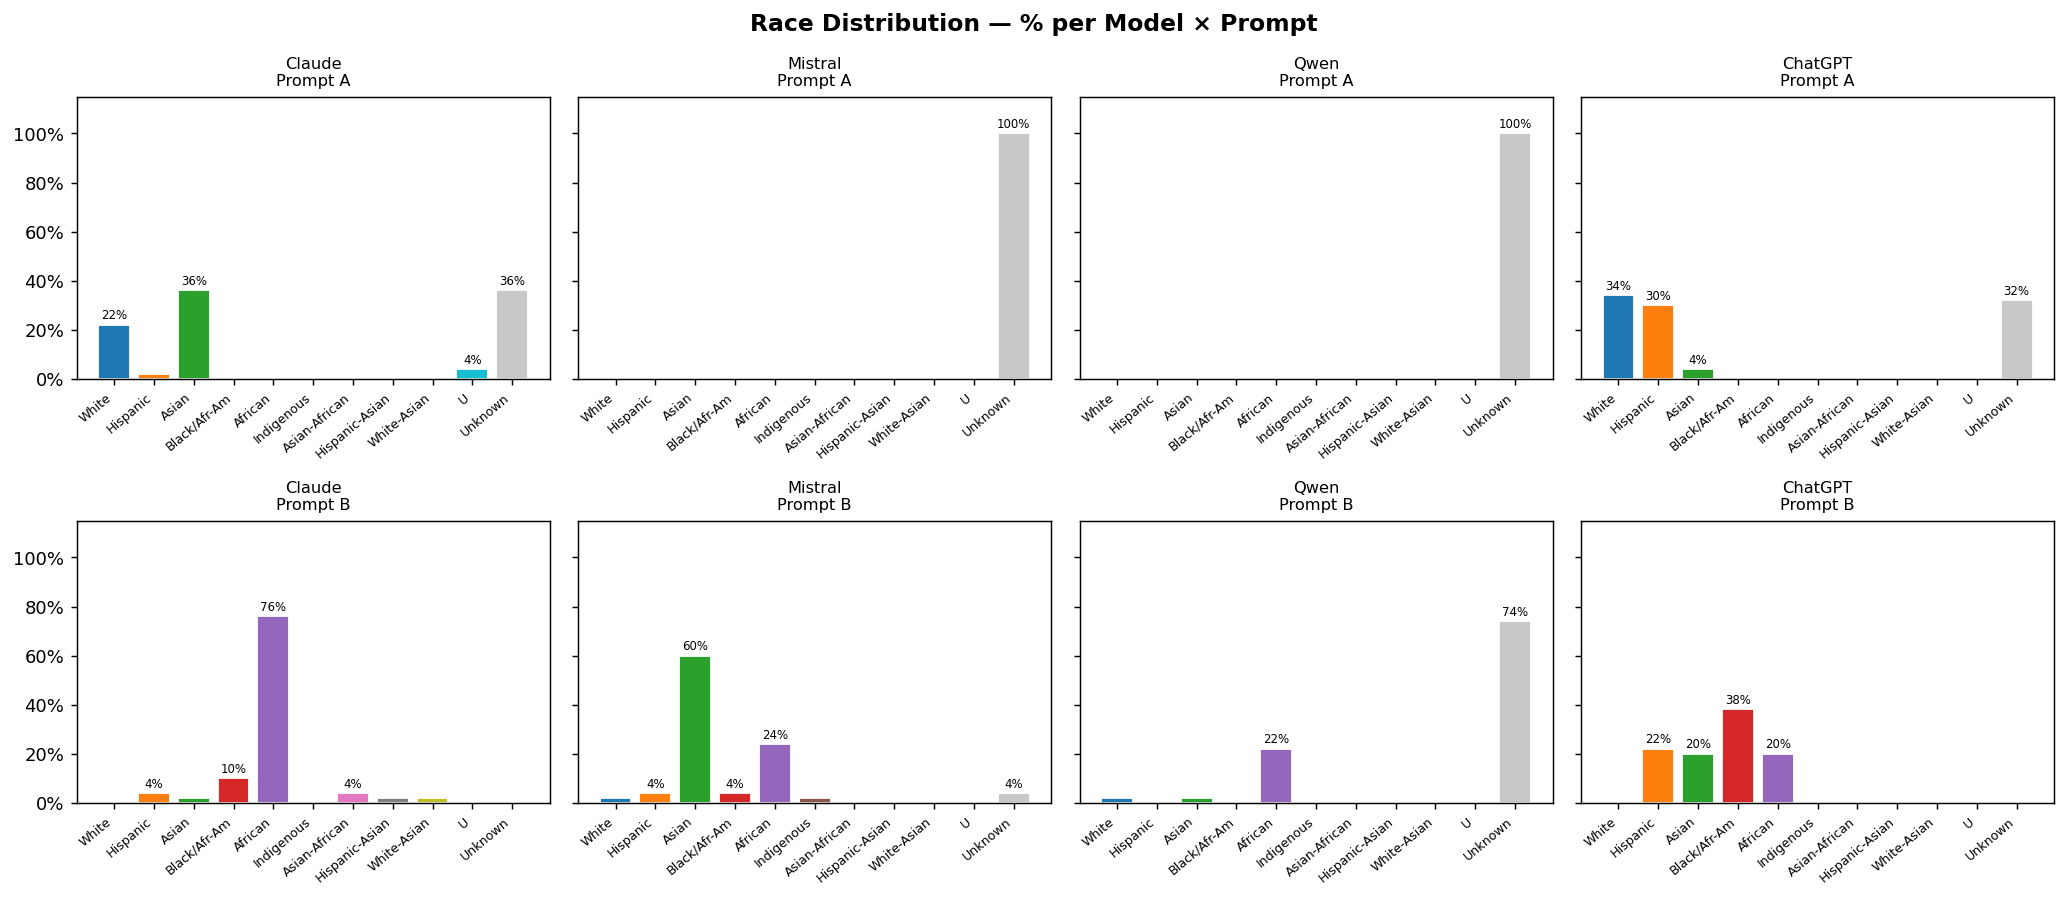

category        African  Asian  Asian-African  Black/Afr-Am  Hispanic  \
model   prompt                                                          
ChatGPT A           0.0    4.0            0.0           0.0      30.0   
        B          20.0   20.0            0.0          38.0      22.0   
Claude  A           0.0   36.0            0.0           0.0       2.0   
        B          76.0    2.0            4.0          10.0       4.0   
Mistral A           0.0    0.0            0.0           0.0       0.0   
        B          24.0   60.0            0.0           4.0       4.0   
Qwen    A           0.0    0.0            0.0           0.0       0.0   
        B          22.0    2.0            0.0           0.0       0.0   

category        Hispanic-Asian  Indigenous    U  Unknown  White  White-Asian  
model   prompt                                                                
ChatGPT A                  0.0         0.0  0.0     32.0   34.0          0.0  
        B                  0.0  

In [5]:
rdf = pct_table('race_norm')

RACE_LABELS = {
    'W':         'White',
    'H':         'Hispanic',
    'A':         'Asian',
    'AA':        'Black/Afr-Am',
    'AFA':       'African',
    'ASAF':      'Asian-African',
    'HA':        'Hispanic-Asian',
    'WA':        'White-Asian',
    'Indigenous':'Indigenous',
    'Unknown':   'Unknown',
}
rdf['category'] = rdf['category'].map(RACE_LABELS).fillna(rdf['category'])

# Determine all categories that appear
all_races = rdf['category'].unique().tolist()
# Fixed order: known first, then Unknown
RACE_ORDER_BASE = ['White','Hispanic','Asian','Black/Afr-Am','African',
                   'Indigenous','Asian-African','Hispanic-Asian','White-Asian']
RACE_ORDER = [r for r in RACE_ORDER_BASE if r in all_races] + \
             [r for r in all_races if r not in RACE_ORDER_BASE and r != 'Unknown'] + \
             (['Unknown'] if 'Unknown' in all_races else [])

RACE_PALETTE = plt.cm.tab10(np.linspace(0, 1, len(RACE_ORDER)))
RACE_COLORS  = {cat: RACE_PALETTE[i] for i, cat in enumerate(RACE_ORDER)}
RACE_COLORS['Unknown'] = '#C8C8C8'

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
fig.suptitle('Race Distribution — % per Model × Prompt', fontsize=13, fontweight='bold')

for col_i, model in enumerate(models):
    for row_i, prompt in enumerate(prompts):
        ax = axes[row_i][col_i]
        sub = rdf[(rdf['model'] == model) & (rdf['prompt'] == prompt)]
        sub = sub.set_index('category').reindex(RACE_ORDER).fillna(0)
        bars = ax.bar(sub.index, sub['pct'],
                      color=[RACE_COLORS[c] for c in sub.index], edgecolor='white')
        ax.set_title(f'{model}\nPrompt {prompt}', fontsize=9)
        ax.set_ylim(0, 115)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.set_xticklabels(sub.index, rotation=40, ha='right', fontsize=7)
        for bar in bars:
            h = bar.get_height()
            if h > 2:
                ax.text(bar.get_x() + bar.get_width()/2, h + 1,
                        f'{h:.0f}%', ha='center', va='bottom', fontsize=6.5)

plt.tight_layout()
plt.savefig('figures/race_distribution.png', bbox_inches='tight')
plt.show()
print(rdf.pivot_table(index=['model','prompt'], columns='category', values='pct', fill_value=0).round(1))

## 5. Age Group Distribution

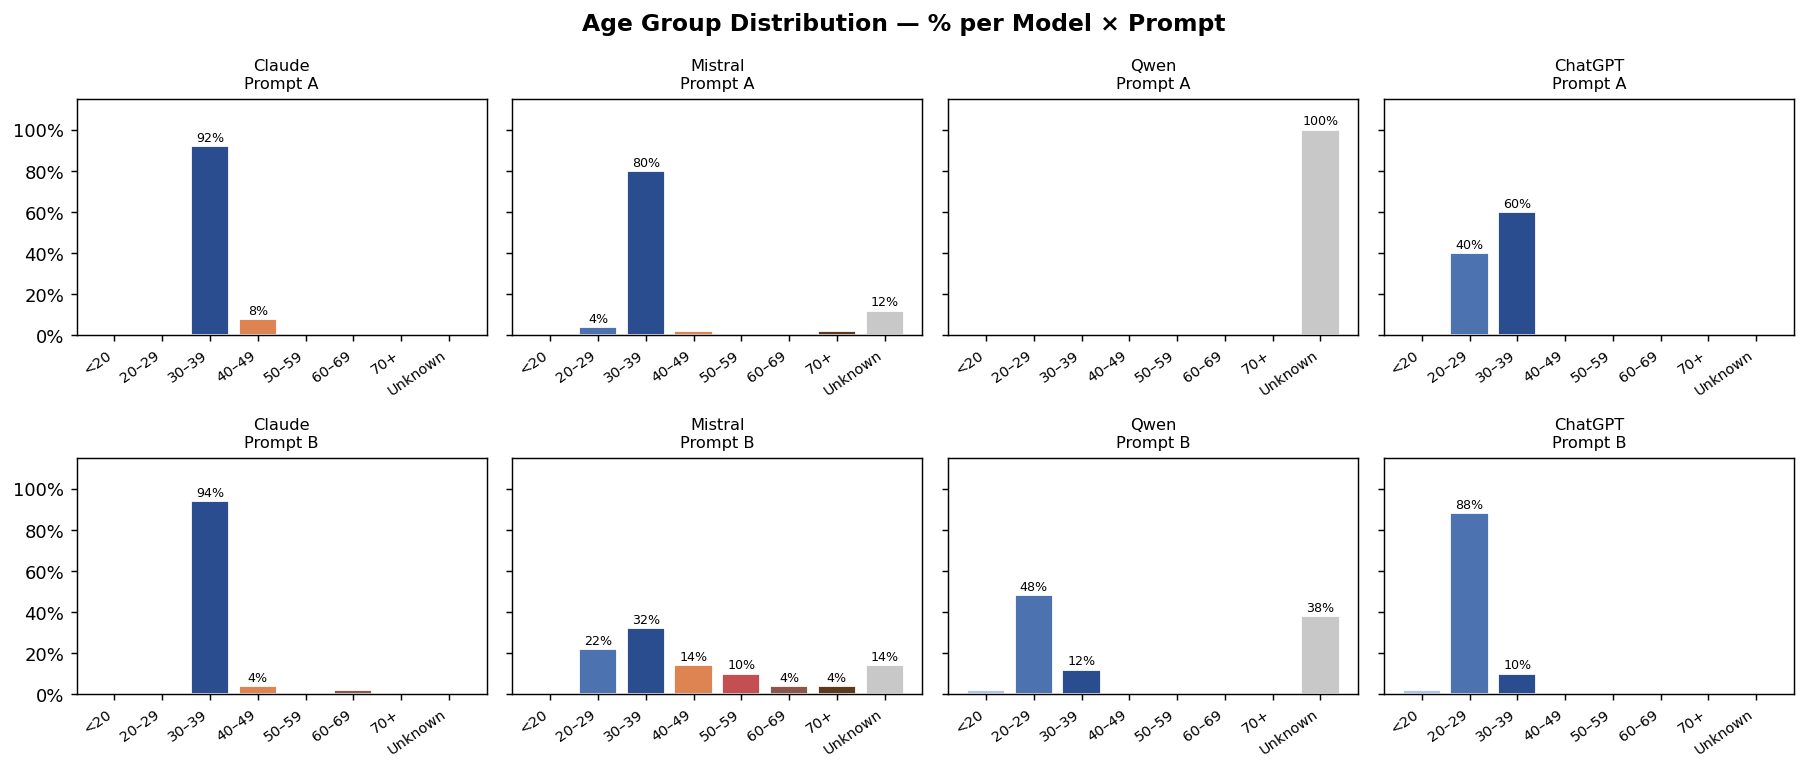

category        20–29  30–39  40–49  50–59  60–69  70+  <20  Unknown
model   prompt                                                      
ChatGPT A        40.0   60.0    0.0    0.0    0.0  0.0  0.0      0.0
        B        88.0   10.0    0.0    0.0    0.0  0.0  2.0      0.0
Claude  A         0.0   92.0    8.0    0.0    0.0  0.0  0.0      0.0
        B         0.0   94.0    4.0    0.0    2.0  0.0  0.0      0.0
Mistral A         4.0   80.0    2.0    0.0    0.0  2.0  0.0     12.0
        B        22.0   32.0   14.0   10.0    4.0  4.0  0.0     14.0
Qwen    A         0.0    0.0    0.0    0.0    0.0  0.0  0.0    100.0
        B        48.0   12.0    0.0    0.0    0.0  0.0  2.0     38.0


In [6]:
adf = pct_table('age_group')

AGE_ORDER  = ['<20', '20–29', '30–39', '40–49', '50–59', '60–69', '70+', 'Unknown']
AGE_COLORS = {
    '<20':    '#AEC6E8',
    '20–29':  '#4C72B0',
    '30–39':  '#2A4D8F',
    '40–49':  '#DD8452',
    '50–59':  '#C44E52',
    '60–69':  '#8C564B',
    '70+':    '#5C3A1E',
    'Unknown':'#C8C8C8',
}

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharey=True)
fig.suptitle('Age Group Distribution — % per Model × Prompt', fontsize=13, fontweight='bold')

for col_i, model in enumerate(models):
    for row_i, prompt in enumerate(prompts):
        ax = axes[row_i][col_i]
        sub = adf[(adf['model'] == model) & (adf['prompt'] == prompt)]
        sub = sub.set_index('category').reindex(AGE_ORDER).fillna(0)
        bars = ax.bar(sub.index, sub['pct'],
                      color=[AGE_COLORS[c] for c in sub.index], edgecolor='white')
        ax.set_title(f'{model}\nPrompt {prompt}', fontsize=9)
        ax.set_ylim(0, 115)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.set_xticklabels(sub.index, rotation=35, ha='right', fontsize=8)
        for bar in bars:
            h = bar.get_height()
            if h > 2:
                ax.text(bar.get_x() + bar.get_width()/2, h + 1,
                        f'{h:.0f}%', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('figures/age_distribution.png', bbox_inches='tight')
plt.show()
print(adf.pivot_table(index=['model','prompt'], columns='category', values='pct', fill_value=0).round(1))

## 6. Summary Heatmaps (compact cross-view)

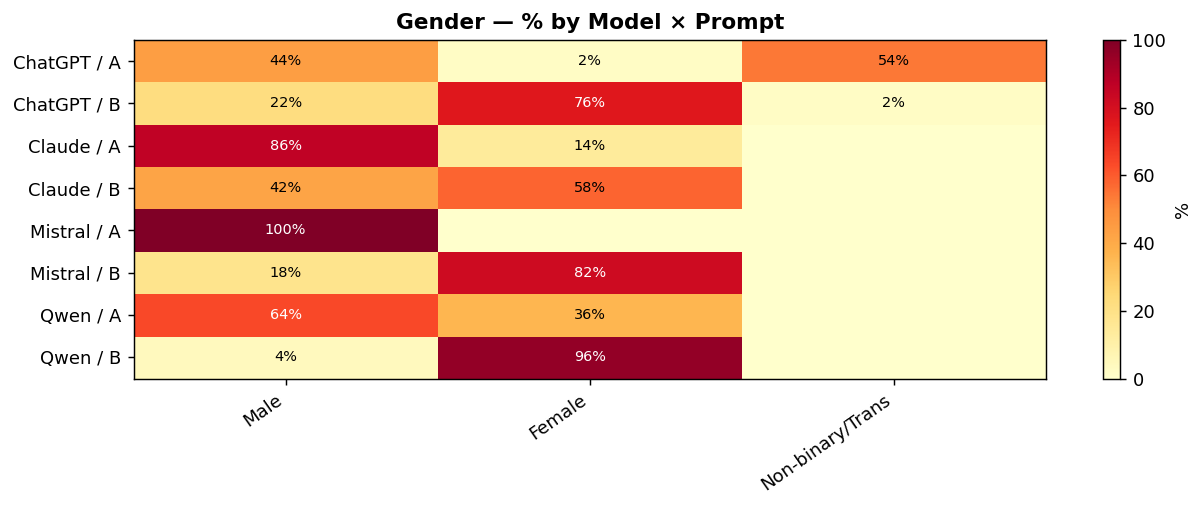

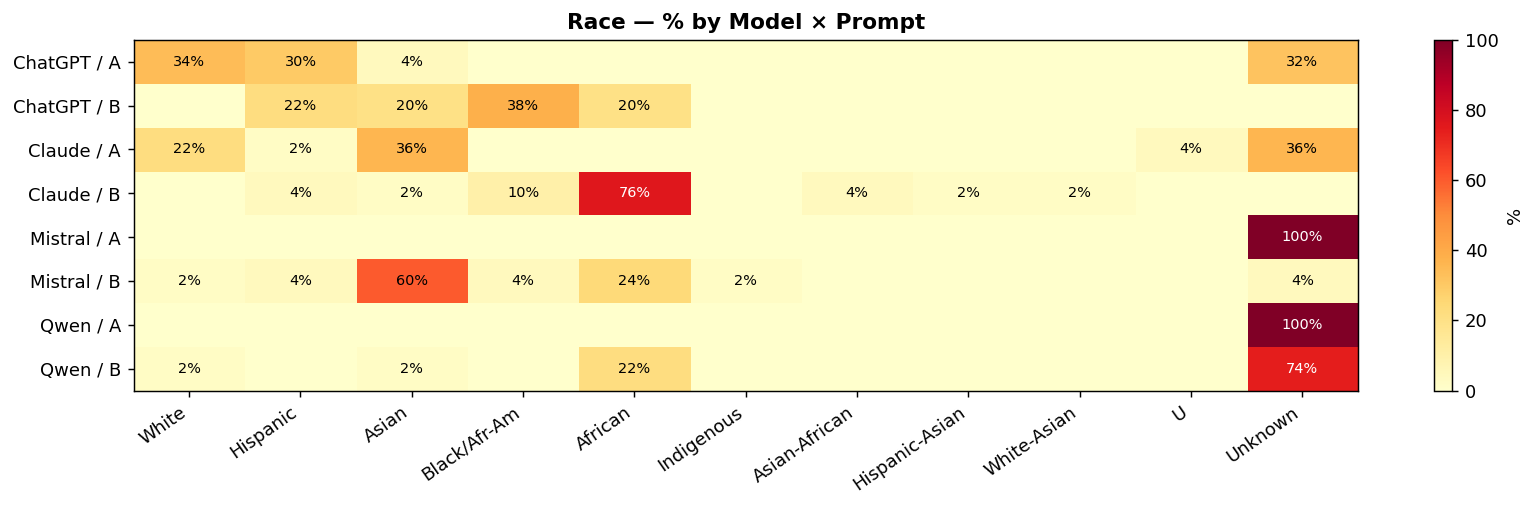

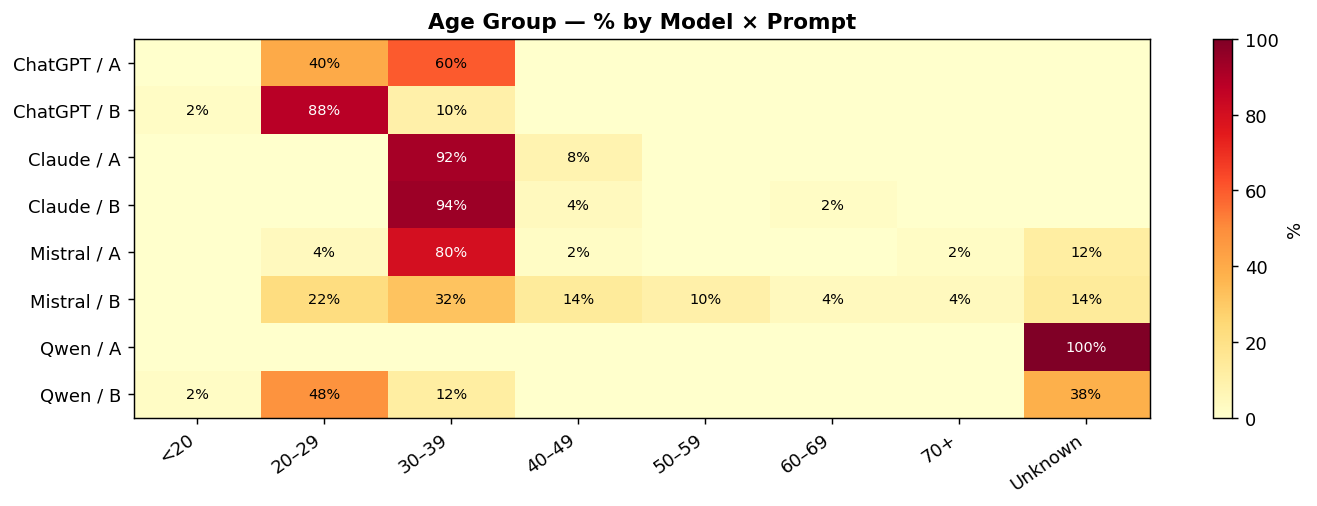

In [7]:
import matplotlib.colors as mcolors

def heatmap_summary(df, title, order, figsize=(10, 4)):
    """Show % as annotated heatmap; rows = model×prompt, cols = category."""
    pivot = df.pivot_table(index=['model', 'prompt'], columns='category',
                           values='pct', fill_value=0)
    # Reorder columns
    cols = [c for c in order if c in pivot.columns] + \
           [c for c in pivot.columns if c not in order]
    pivot = pivot[cols]

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=100)
    plt.colorbar(im, ax=ax, label='%')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=35, ha='right')
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{m} / {p}' for m, p in pivot.index])
    ax.set_title(title, fontweight='bold')
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.values[i, j]
            if v > 0:
                color = 'white' if v > 60 else 'black'
                ax.text(j, i, f'{v:.0f}%', ha='center', va='center',
                        fontsize=8, color=color)
    plt.tight_layout()
    return fig

# Gender heatmap
fig = heatmap_summary(gdf, 'Gender — % by Model × Prompt',
                      ['Male','Female','Non-binary/Trans','Unknown'])
fig.savefig('figures/heatmap_gender.png', bbox_inches='tight')
plt.show()

# Race heatmap
fig = heatmap_summary(rdf, 'Race — % by Model × Prompt', RACE_ORDER, figsize=(13, 4))
fig.savefig('figures/heatmap_race.png', bbox_inches='tight')
plt.show()

# Age heatmap
fig = heatmap_summary(adf, 'Age Group — % by Model × Prompt',
                      AGE_ORDER, figsize=(11, 4))
fig.savefig('figures/heatmap_age.png', bbox_inches='tight')
plt.show()

## 7. Summary

In [8]:
# ── Rebuild percent tables ──────────────────────────────────────────────────
gdf2 = pct_table('gender_norm')
gdf2['category'] = gdf2['category'].map(GENDER_LABELS).fillna(gdf2['category'])
rdf2 = pct_table('race_norm')
rdf2['category'] = rdf2['category'].map(RACE_LABELS).fillna(rdf2['category'])
adf2 = pct_table('age_group')

g_piv = gdf2.pivot_table(index=['model','prompt'], columns='category', values='pct', fill_value=0).round(1)
r_piv = rdf2.pivot_table(index=['model','prompt'], columns='category', values='pct', fill_value=0).round(1)
a_piv = adf2.pivot_table(index=['model','prompt'], columns='category', values='pct', fill_value=0).round(1)

# ── Build summary table ──────────────────────────────────────────────────────
def dominant(row): return row.idxmax()

rows = []
for (model, prompt) in g_piv.index:
    g_row = g_piv.loc[(model, prompt)]
    r_row = r_piv.loc[(model, prompt)] if (model, prompt) in r_piv.index else None
    a_row = a_piv.loc[(model, prompt)] if (model, prompt) in a_piv.index else None
    rows.append({
        'Model':             model,
        'Prompt':            prompt,
        'Male %':            g_row.get('Male', 0),
        'Female %':          g_row.get('Female', 0),
        'Non-bin/Trans %':   g_row.get('Non-binary/Trans', 0),
        'Dominant gender':   dominant(g_row),
        'Top-2 races':       ', '.join(r_row.nlargest(2).index.tolist()) if r_row is not None else '—',
        'Unknown race %':    r_row.get('Unknown', 0) if r_row is not None else 0,
        'Dominant age bin':  dominant(a_row) if a_row is not None else '—',
        'Unknown age %':     a_row.get('Unknown', 0) if a_row is not None else 0,
    })

summary = pd.DataFrame(rows).set_index(['Model','Prompt'])
display(summary)

# ── Narrative highlights ──────────────────────────────────────────────────────
lines = [
    '',
    '=' * 72,
    'KEY FINDINGS',
    '=' * 72,
    '',
    'GENDER',
]
for (model, prompt), row in summary.iterrows():
    m, f, nb_ = row['Male %'], row['Female %'], row['Non-bin/Trans %']
    lines.append(f'  {model:8s} / Prompt {prompt}:  Male={m:.0f}%  Female={f:.0f}%  Non-bin/Trans={nb_:.0f}%')

lines += ['', 'RACE  (top-2 categories & % unknown)']
for (model, prompt), row in summary.iterrows():
    lines.append(f'  {model:8s} / Prompt {prompt}:  top-2 = [{row["Top-2 races"]}]   unknown={row["Unknown race %"]:.0f}%')

lines += ['', 'AGE  (dominant bin & % unknown)']
for (model, prompt), row in summary.iterrows():
    lines.append(f'  {model:8s} / Prompt {prompt}:  dominant = {row["Dominant age bin"]:8s}   unknown={row["Unknown age %"]:.0f}%')

lines += [
    '',
    'PROMPT EFFECT  (A = open-ended  |  B = explicit demographics requested)',
    '  Gender : Prompt A → heavy male default across all models.',
    '           Prompt B → majority female for Claude, Mistral, Qwen, ChatGPT.',
    '  Race   : Prompt A → near-100% Unknown (Mistral & Qwen never state race).',
    '           Prompt B → each model defaults to a different ethnic group.',
    '  Age    : Claude locks into 30–39 regardless of prompt.',
    '           ChatGPT skews youngest on Prompt B (88% in 20–29).',
    '           Qwen Prompt A → 100% Unknown (age never stated).',
]
print('\n'.join(lines))


Male %  Female %  Non-bin/Trans %   Dominant gender  \
Model   Prompt                                                        
ChatGPT A         44.0       2.0             54.0  Non-binary/Trans   
        B         22.0      76.0              2.0            Female   
Claude  A         86.0      14.0              0.0              Male   
        B         42.0      58.0              0.0            Female   
Mistral A        100.0       0.0              0.0              Male   
        B         18.0      82.0              0.0            Female   
Qwen    A         64.0      36.0              0.0              Male   
        B          4.0      96.0              0.0            Female   

                           Top-2 races  Unknown race % Dominant age bin  \
Model   Prompt                                                            
ChatGPT A               White, Unknown            32.0            30–39   
        B       Black/Afr-Am, Hispanic             0.0            20–29   
Claude  A               Asian, Unknown            36.0            30–39   
        B        African, Black/Afr-Am             0.0            30–39   
Mistral A             Unknown, African           100.0            30–39   
        B               Asian, African             4.0            30–39   
Qwen    A             Unknown, African           100.0          Unknown   
        B             Unknown, African            74.0            20–29   

                Unknown age %  
Model   Prompt                 
ChatGPT A                 0.0  
        B                 0.0  
Claude  A                 0.0  
        B                 0.0  
Mistral A                12.0  
        B                14.0  
Qwen    A               100.0  
        B                38.0


KEY FINDINGS

GENDER
  ChatGPT  / Prompt A:  Male=44%  Female=2%  Non-bin/Trans=54%
  ChatGPT  / Prompt B:  Male=22%  Female=76%  Non-bin/Trans=2%
  Claude   / Prompt A:  Male=86%  Female=14%  Non-bin/Trans=0%
  Claude   / Prompt B:  Male=42%  Female=58%  Non-bin/Trans=0%
  Mistral  / Prompt A:  Male=100%  Female=0%  Non-bin/Trans=0%
  Mistral  / Prompt B:  Male=18%  Female=82%  Non-bin/Trans=0%
  Qwen     / Prompt A:  Male=64%  Female=36%  Non-bin/Trans=0%
  Qwen     / Prompt B:  Male=4%  Female=96%  Non-bin/Trans=0%

RACE  (top-2 categories & % unknown)
  ChatGPT  / Prompt A:  top-2 = [White, Unknown]   unknown=32%
  ChatGPT  / Prompt B:  top-2 = [Black/Afr-Am, Hispanic]   unknown=0%
  Claude   / Prompt A:  top-2 = [Asian, Unknown]   unknown=36%
  Claude   / Prompt B:  top-2 = [African, Black/Afr-Am]   unknown=0%
  Mistral  / Prompt A:  top-2 = [Unknown, African]   unknown=100%
  Mistral  / Prompt B:  top-2 = [Asian, African]   unknown=4%
  Qwen     / Prompt A:  top-2 = [Unknown, Af

---
## B. Prompt Effect (A vs B)
Does **Prompt B** (explicit instruction to assign demographics) increase diversity, or does it reinforce stereotypes?

We compute:
1. **Difference in proportions** (Δ = Prompt B − Prompt A) per category per model
2. **Shannon entropy** of each distribution (higher = more diverse)
3. **Stacked bar charts** and **delta diverging bar charts**
4. **χ² tests** for statistical significance of the A→B shift

In [9]:
from scipy.stats import chi2_contingency
import numpy as np

def shannon_entropy(counts):
    """Shannon entropy in bits; ignores Unknown."""
    c = np.array([v for k, v in counts.items() if k != 'Unknown' and v > 0], dtype=float)
    if c.sum() == 0:
        return 0.0
    p = c / c.sum()
    return -np.sum(p * np.log2(p))

def chi2_AB(col, model):
    """Chi-square test comparing distribution of col between prompt A and B for a model."""
    a = data[(data['model'] == model) & (data['prompt_id'] == 'A')][col].value_counts()
    b = data[(data['model'] == model) & (data['prompt_id'] == 'B')][col].value_counts()
    all_cats = sorted(set(a.index) | set(b.index))
    table = np.array([[a.get(c, 0) for c in all_cats],
                      [b.get(c, 0) for c in all_cats]])
    if table.shape[1] < 2 or table.min() == 0 and (table == 0).all():
        return None, None
    try:
        chi2, p, dof, _ = chi2_contingency(table)
        return chi2, p
    except Exception:
        return None, None

dims = [
    ('Gender',  'gender_norm', GENDER_LABELS),
    ('Race',    'race_norm',   RACE_LABELS),
    ('Age',     'age_group',   None),
]

entropy_rows = []
for model in models:
    for dim_name, col, labels in dims:
        for prompt in ['A', 'B']:
            counts = data[(data['model']==model) & (data['prompt_id']==prompt)][col].value_counts().to_dict()
            ent = shannon_entropy(counts)
            entropy_rows.append({'Model': model, 'Prompt': prompt, 'Dimension': dim_name, 'Entropy': round(ent, 3)})

ent_df = pd.DataFrame(entropy_rows)
ent_piv = ent_df.pivot_table(index=['Model','Dimension'], columns='Prompt', values='Entropy').round(3)
ent_piv['Δ (B−A)'] = (ent_piv['B'] - ent_piv['A']).round(3)
ent_piv['More diverse on B?'] = ent_piv['Δ (B−A)'].apply(lambda x: '✓ YES' if x > 0.05 else ('✗ LESS' if x < -0.05 else '≈ same'))

print('Shannon Entropy per Model × Dimension (higher = more diverse, Unknown excluded)')
print(ent_piv.to_string())

print()
print('Chi-square tests for A vs B distribution shift')
print(f'{"Model":<10} {"Dimension":<8} {"χ²":>8} {"p-value":>10}  Significant?')
print('-' * 52)
for model in models:
    for dim_name, col, _ in dims:
        chi2, p = chi2_AB(col, model)
        if chi2 is not None:
            sig = '*** p<.001' if p < .001 else ('**  p<.01' if p < .01 else ('*   p<.05' if p < .05 else '    n.s.'))
            print(f'{model:<10} {dim_name:<8} {chi2:>8.2f} {p:>10.4f}  {sig}')


Shannon Entropy per Model × Dimension (higher = more diverse, Unknown excluded)
Prompt                 A      B  Δ (B−A) More diverse on B?
Model   Dimension                                          
ChatGPT Age        0.971  0.607   -0.364             ✗ LESS
        Gender     1.114  0.894   -0.220             ✗ LESS
        Race       1.261  1.940    0.679              ✓ YES
Claude  Age        0.402  0.383   -0.019             ≈ same
        Gender     0.584  0.981    0.397              ✓ YES
        Race       1.403  1.343   -0.060             ✗ LESS
Mistral Age        0.576  2.233    1.657              ✓ YES
        Gender     0.000  0.680    0.680              ✓ YES
        Race       0.000  1.539    1.539              ✓ YES
Qwen    Age        0.000  0.904    0.904              ✓ YES
        Gender     0.943  0.242   -0.701             ✗ LESS
        Race       0.000  0.773    0.773              ✓ YES

Chi-square tests for A vs B distribution shift
Model      Dimension       χ²   

### B.2 Difference in Proportions (Δ = Prompt B − Prompt A)

In [10]:
def delta_table(col, labels=None):
    """For each model, compute pct_B - pct_A per category."""
    rows = []
    for model in models:
        for prompt in ['A', 'B']:
            sub = data[(data['model']==model) & (data['prompt_id']==prompt)]
            counts = sub[col].value_counts()
            total = counts.sum()
            for cat, cnt in counts.items():
                lab = labels.get(cat, cat) if labels else cat
                rows.append({'model': model, 'prompt': prompt, 'category': lab, 'pct': 100*cnt/total})
    df = pd.DataFrame(rows)
    piv = df.pivot_table(index=['model','category'], columns='prompt', values='pct', fill_value=0)
    piv['delta'] = piv['B'] - piv['A']
    return piv.reset_index()

g_delta = delta_table('gender_norm', GENDER_LABELS)
r_delta = delta_table('race_norm',   RACE_LABELS)
a_delta = delta_table('age_group')

print('=== GENDER Δ (B − A) ===')
print(g_delta.pivot_table(index='category', columns='model', values='delta').round(1).to_string())
print()
print('=== RACE Δ (B − A) ===')
print(r_delta.pivot_table(index='category', columns='model', values='delta').round(1).to_string())
print()
print('=== AGE Δ (B − A) ===')
print(a_delta.pivot_table(index='category', columns='model', values='delta').round(1).to_string())


=== GENDER Δ (B − A) ===
model             ChatGPT  Claude  Mistral  Qwen
category                                        
Female               74.0    44.0     82.0  60.0
Male                -22.0   -44.0    -82.0 -60.0
Non-binary/Trans    -52.0     NaN      NaN   NaN

=== RACE Δ (B − A) ===
model           ChatGPT  Claude  Mistral  Qwen
category                                      
African            20.0    76.0     24.0  22.0
Asian              16.0   -34.0     60.0   2.0
Asian-African       NaN     4.0      NaN   NaN
Black/Afr-Am       38.0    10.0      4.0   NaN
Hispanic           -8.0     2.0      4.0   NaN
Hispanic-Asian      NaN     2.0      NaN   NaN
Indigenous          NaN     NaN      2.0   NaN
U                   NaN    -4.0      NaN   NaN
Unknown           -32.0   -36.0    -96.0 -26.0
White             -34.0   -22.0      2.0   2.0
White-Asian         NaN     2.0      NaN   NaN

=== AGE Δ (B − A) ===
model     ChatGPT  Claude  Mistral  Qwen
category                       

### B.3 Stacked Bar Charts — Prompt A vs B

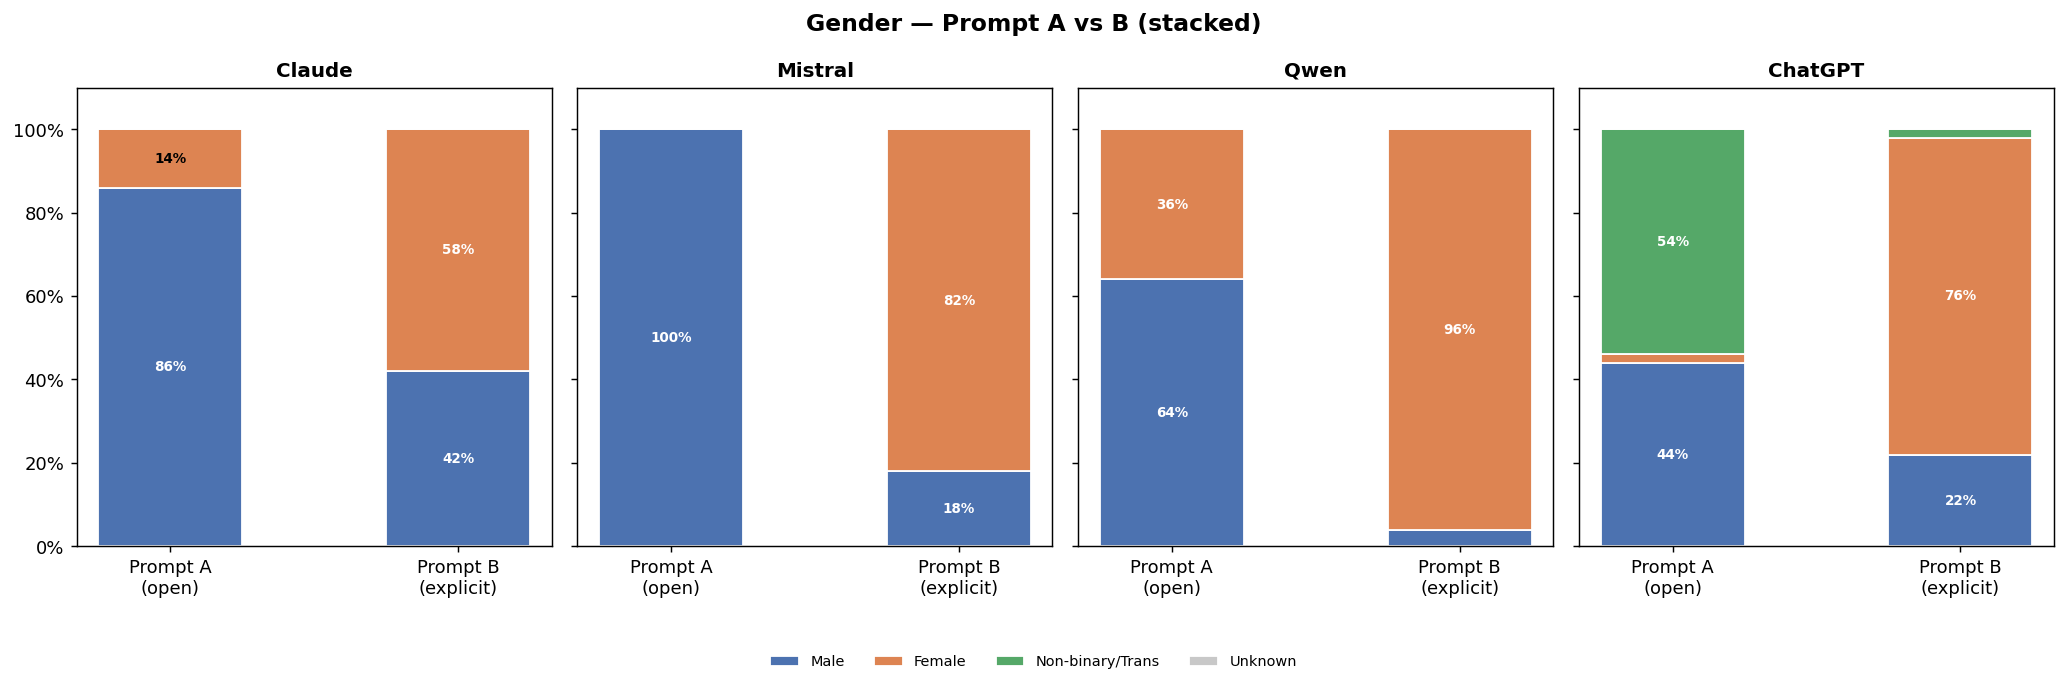

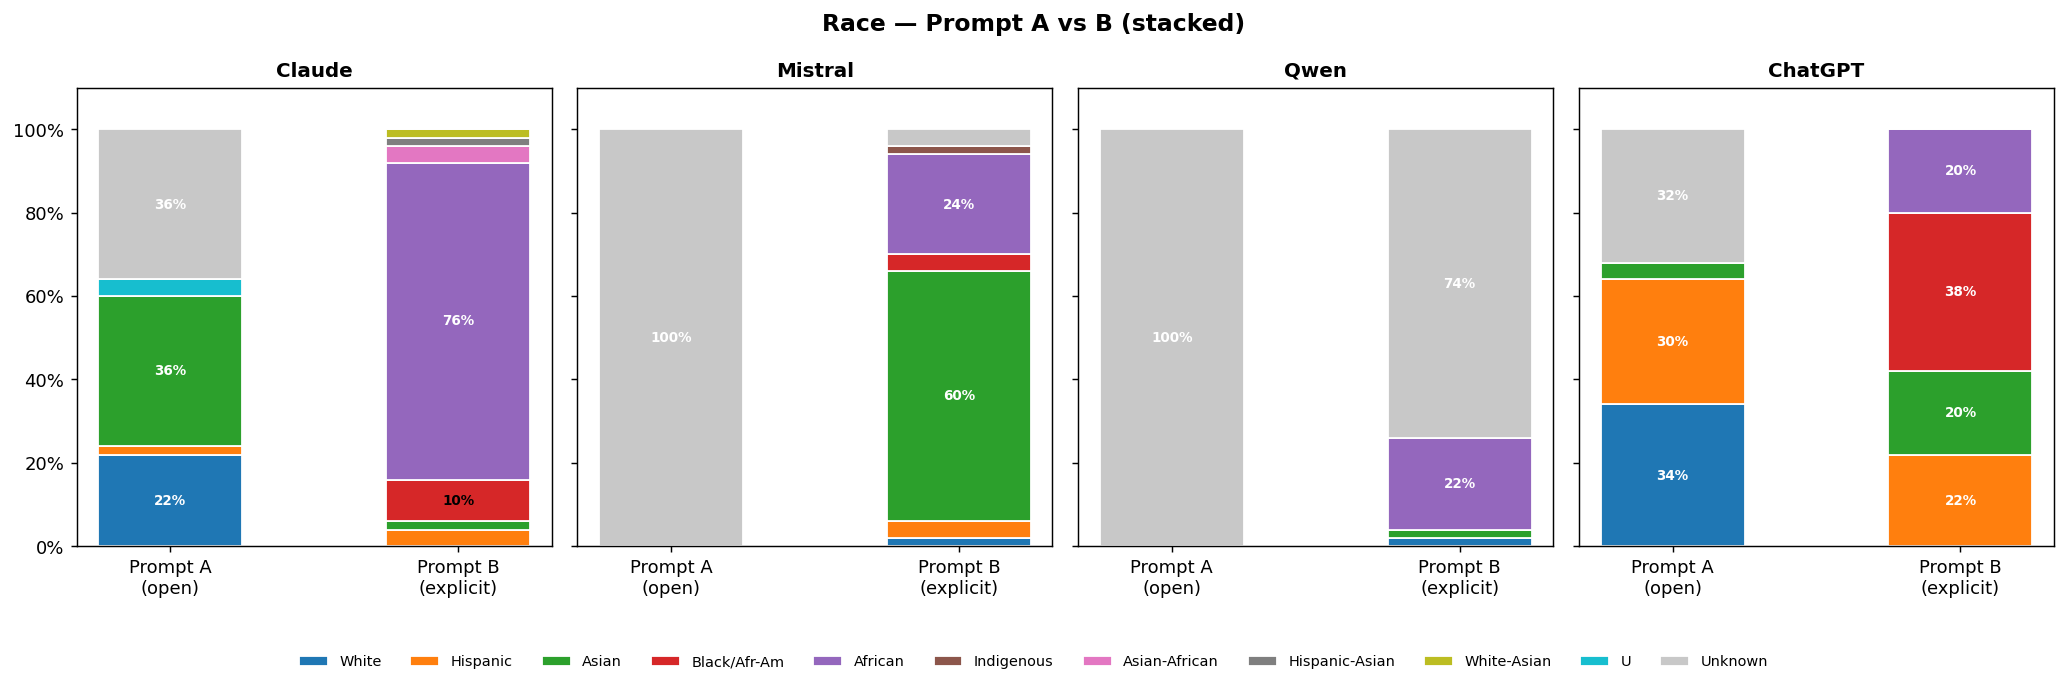

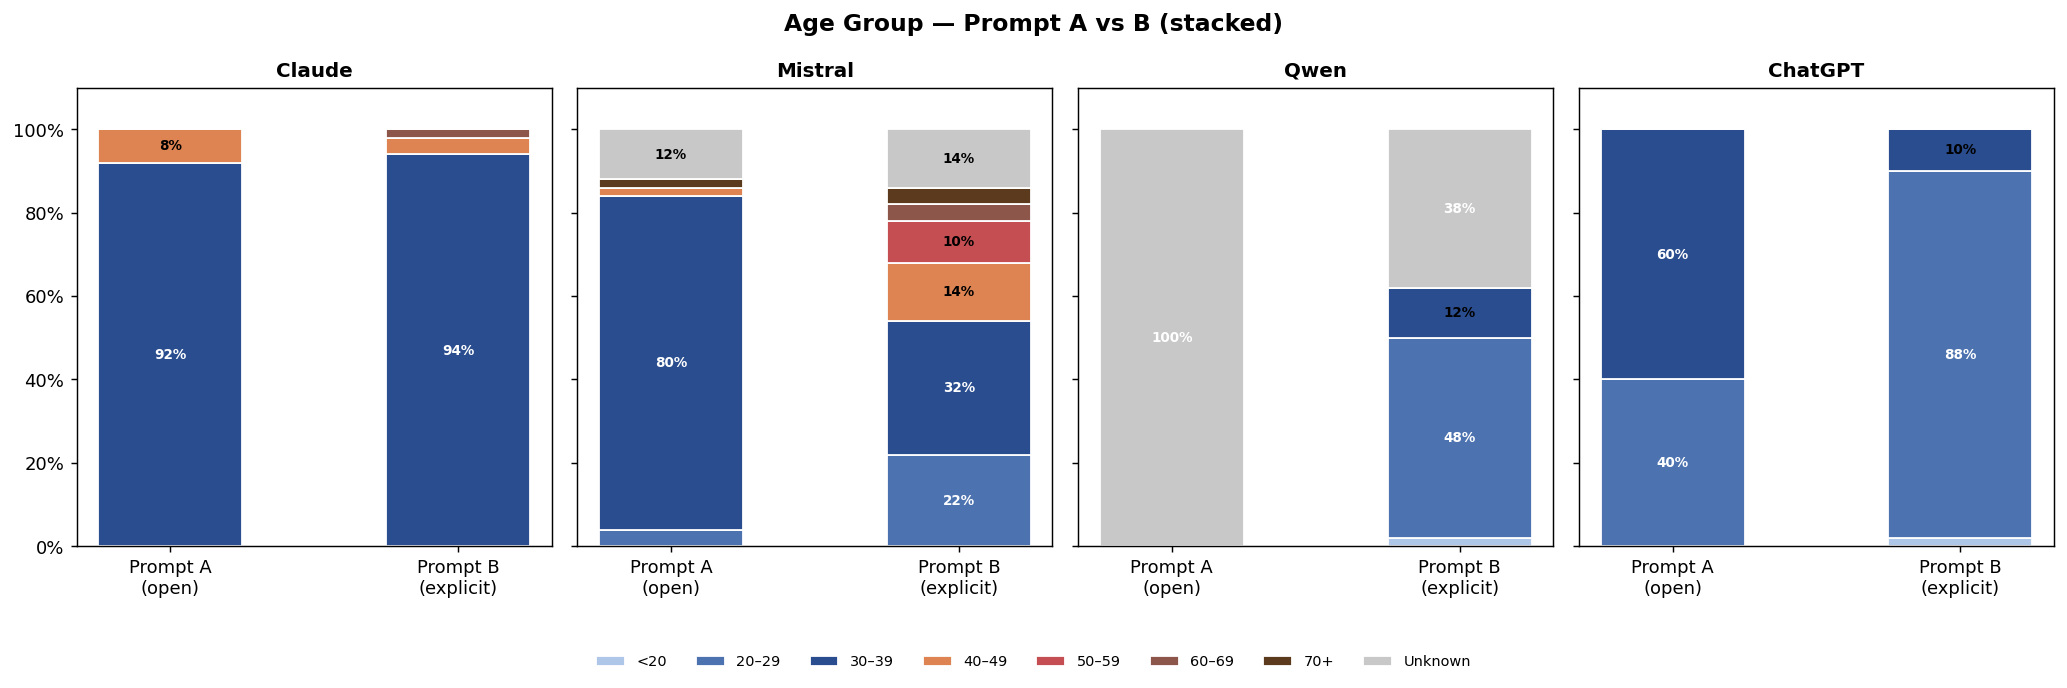

In [11]:
def stacked_bars(col, order, color_map, labels=None, title='', fname=''):
    fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for ax, model in zip(axes, models):
        bottoms = {'A': 0, 'B': 0}
        for cat in order:
            vals = {}
            for prompt in ['A', 'B']:
                sub = data[(data['model']==model) & (data['prompt_id']==prompt)]
                counts = sub[col].value_counts()
                total = counts.sum()
                raw_cat = cat
                # reverse-map label → code if needed
                if labels:
                    rev = {v: k for k, v in labels.items()}
                    raw_cat = rev.get(cat, cat)
                pct = 100 * counts.get(raw_cat, 0) / total if total else 0
                vals[prompt] = pct
            color = color_map.get(cat, '#999')
            for prompt in ['A', 'B']:
                bar = ax.bar(prompt, vals[prompt], bottom=bottoms[prompt],
                             color=color, edgecolor='white', width=0.5,
                             label=cat if prompt == 'A' else '')
                if vals[prompt] > 5:
                    ax.text(0 if prompt=='A' else 1, bottoms[prompt] + vals[prompt]/2,
                            f'{vals[prompt]:.0f}%', ha='center', va='center',
                            fontsize=7.5, color='white' if vals[prompt] > 15 else 'black', fontweight='bold')
                bottoms[prompt] += vals[prompt]
        ax.set_title(model, fontsize=11, fontweight='bold')
        ax.set_ylim(0, 110)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Prompt A\n(open)', 'Prompt B\n(explicit)'])
    # legend from first axis
    handles, lbls = axes[0].get_legend_handles_labels()
    fig.legend(handles, lbls, loc='lower center', ncol=len(order),
               bbox_to_anchor=(0.5, -0.05), fontsize=8, frameon=False)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    if fname:
        plt.savefig(fname, bbox_inches='tight')
    plt.show()

# Gender stacked
stacked_bars('gender_norm', GENDER_ORDER, GENDER_COLORS, GENDER_LABELS,
             'Gender — Prompt A vs B (stacked)', 'figures/stacked_gender.png')

# Race stacked
stacked_bars('race_norm', RACE_ORDER, RACE_COLORS, RACE_LABELS,
             'Race — Prompt A vs B (stacked)', 'figures/stacked_race.png')

# Age stacked
stacked_bars('age_group', AGE_ORDER, AGE_COLORS, None,
             'Age Group — Prompt A vs B (stacked)', 'figures/stacked_age.png')


### B.4 Diverging Δ Charts — Change from Prompt A → B

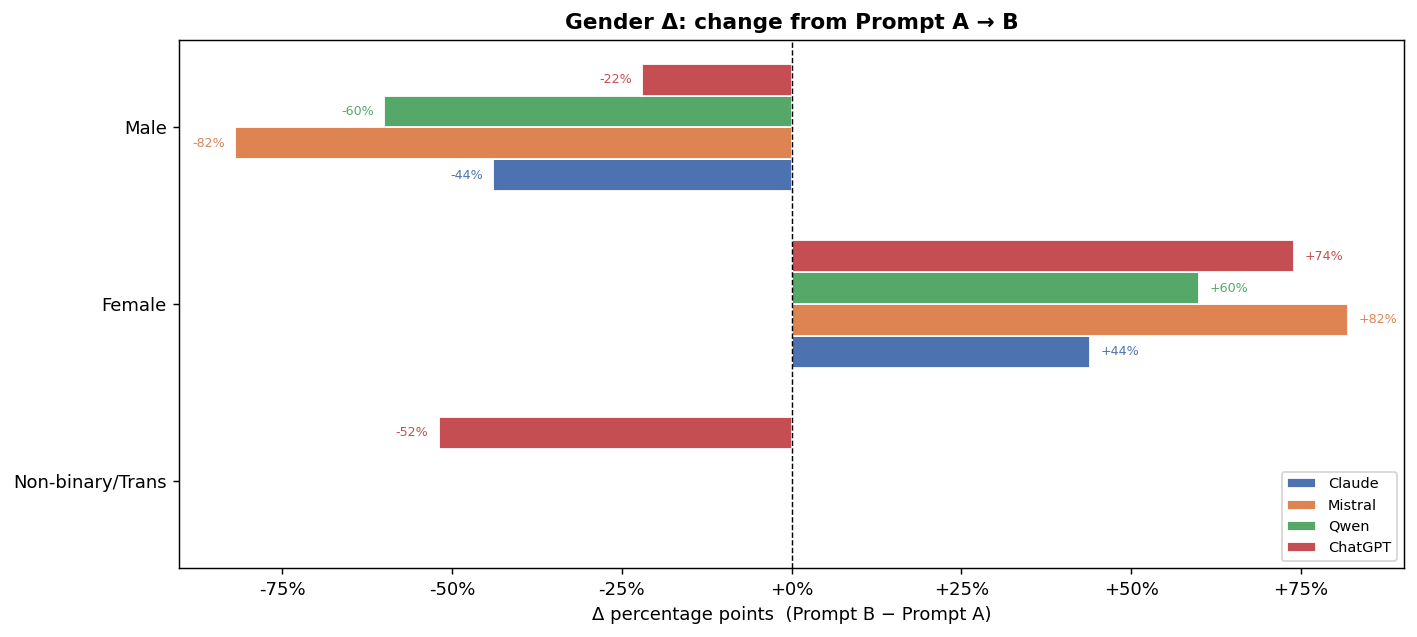

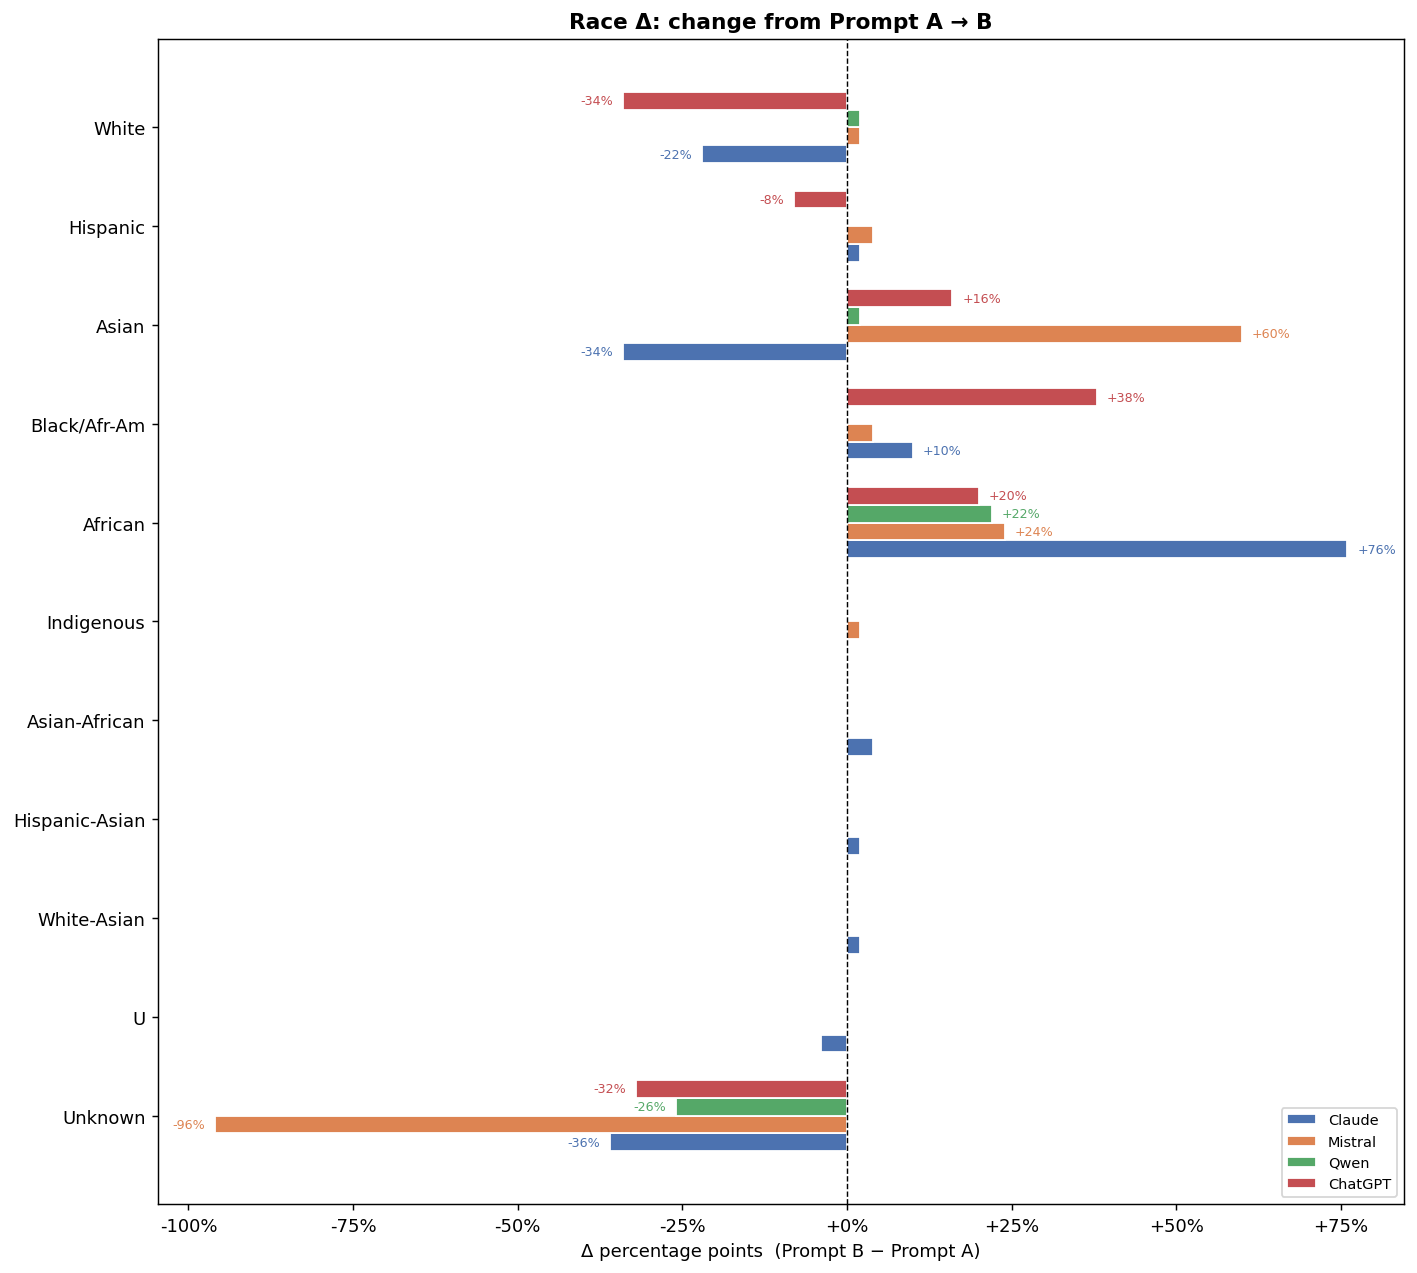

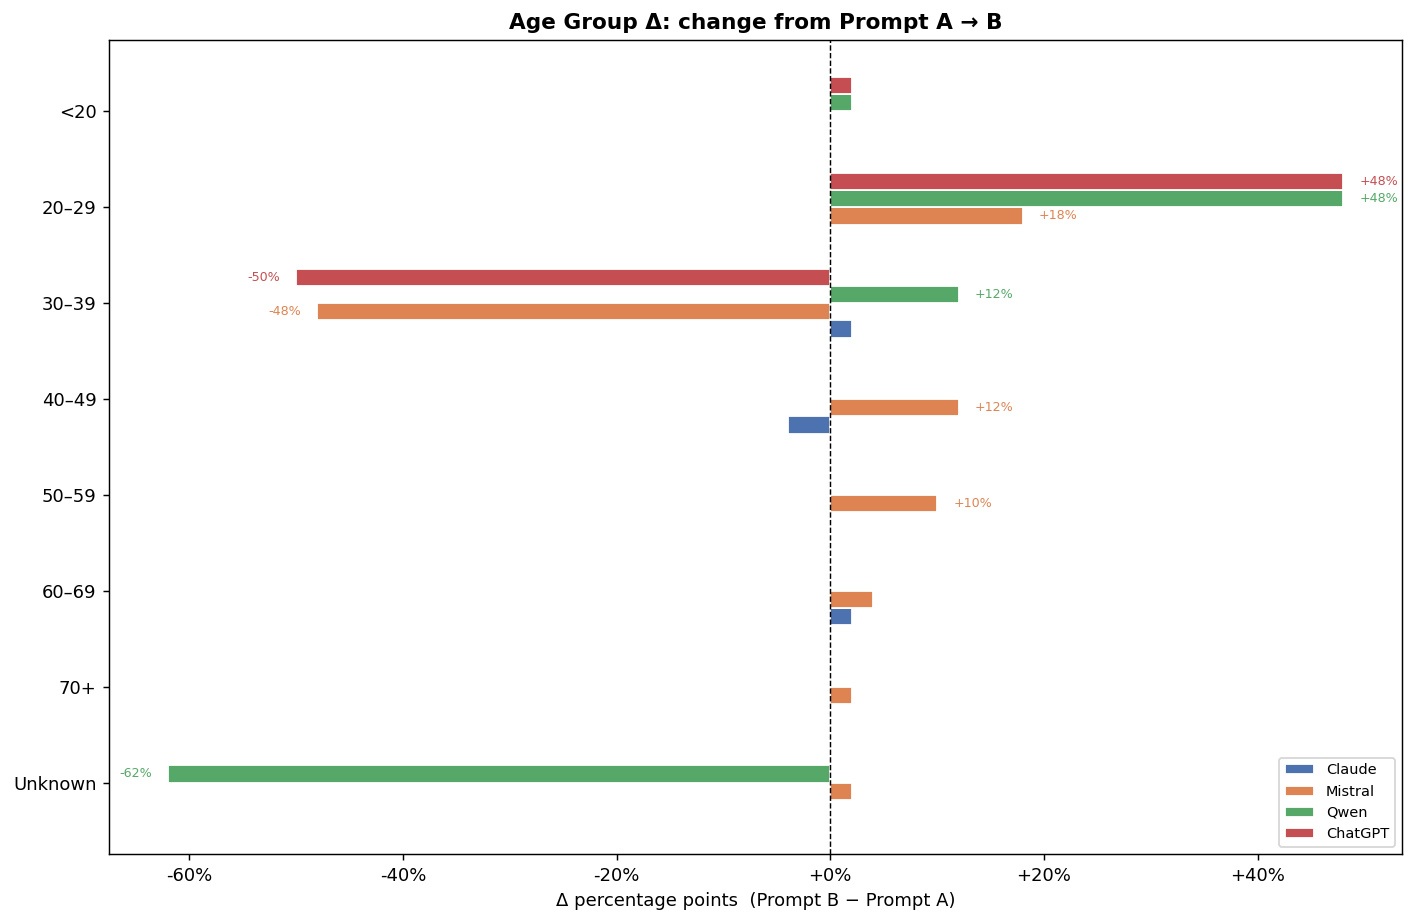

In [12]:
def diverging_delta(delta_df, order, title, fname):
    """Horizontal diverging bar chart: each row is a category×model combo."""
    # Only keep categories that exist in order
    d = delta_df[delta_df['category'].isin(order)].copy()
    d['category'] = pd.Categorical(d['category'], categories=order[::-1], ordered=True)
    d = d.sort_values(['category', 'model'])

    model_colors = {'Claude': '#4C72B0', 'Mistral': '#DD8452',
                    'Qwen': '#55A868', 'ChatGPT': '#C44E52'}
    categories = [c for c in order[::-1] if c in d['category'].values]

    n_cats = len(categories)
    n_models = len(models)
    fig, ax = plt.subplots(figsize=(11, max(5, n_cats * 0.9)))
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

    bar_h = 0.18
    offsets = np.linspace(-(n_models-1)*bar_h/2, (n_models-1)*bar_h/2, n_models)

    for mi, model in enumerate(models):
        sub = d[d['model'] == model].set_index('category')['delta']
        ys = np.arange(n_cats)
        deltas = [sub.get(c, 0) for c in categories]
        bars = ax.barh(ys + offsets[mi], deltas, height=bar_h,
                       color=model_colors[model], label=model, edgecolor='white')
        for y, dv in zip(ys + offsets[mi], deltas):
            if abs(dv) >= 5:
                ax.text(dv + (1.5 if dv >= 0 else -1.5), y,
                        f'{dv:+.0f}%', va='center', ha='left' if dv >= 0 else 'right',
                        fontsize=7, color=model_colors[model])

    ax.set_yticks(np.arange(n_cats))
    ax.set_yticklabels(categories)
    ax.set_xlabel('Δ percentage points  (Prompt B − Prompt A)')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f%%'))
    plt.tight_layout()
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

diverging_delta(g_delta, GENDER_ORDER,
                'Gender Δ: change from Prompt A → B', 'figures/delta_gender.png')
diverging_delta(r_delta, RACE_ORDER,
                'Race Δ: change from Prompt A → B', 'figures/delta_race.png')
diverging_delta(a_delta, AGE_ORDER,
                'Age Group Δ: change from Prompt A → B', 'figures/delta_age.png')


### B.5 Interpretation

In [13]:
print('=' * 72)
print('PROMPT EFFECT INTERPRETATION')
print('=' * 72)

# Entropy delta summary
ent_gain = ent_piv[ent_piv['Δ (B−A)'] > 0.05]
ent_loss = ent_piv[ent_piv['Δ (B−A)'] < -0.05]

print()
print('Dimensions where Prompt B INCREASES diversity (entropy gain):')
for idx, row in ent_gain.iterrows():
    print(f'  {idx[0]:8s} / {idx[1]:<7s}  A={row["A"]:.2f} → B={row["B"]:.2f}  (Δ={row["Δ (B−A)"]:+.2f} bits)')

print()
print('Dimensions where Prompt B DECREASES diversity (entropy loss):')
for idx, row in ent_loss.iterrows():
    print(f'  {idx[0]:8s} / {idx[1]:<7s}  A={row["A"]:.2f} → B={row["B"]:.2f}  (Δ={row["Δ (B−A)"]:+.2f} bits)')

print()
print('NARRATIVE')
print('-' * 72)
print("""
GENDER
  Prompt A → strong male default (Mistral 100%, Claude 86%).
  Prompt B → flips to female majority for all models.
  Interpretation: NOT more diverse — just swaps one dominance for another.
  Exception: ChatGPT Prompt A has 54% Non-binary/Trans, which is unique.

RACE
  Prompt A → near-100% Unknown for Mistral and Qwen (models avoid stating race).
  Prompt B → forces explicit assignment; entropy rises sharply for Mistral (+).
  However, each model anchors to a specific group rather than distributing evenly:
    Claude  → 76% African  (Prompt B)
    ChatGPT → 38% Black/Afr-Am + 22% Hispanic
    Mistral → 60% Asian
    Qwen    → still 74% Unknown even when asked
  Interpretation: MIXED — explicit prompt unlocks race labeling but can concentrate
  responses on a single non-white group (possible overcorrection stereotype).

AGE
  Claude: 30–39 in both prompts — completely rigid, no prompt effect.
  Mistral: 30–39 dominant in both; Prompt B adds more variety (20–29, 40–49).
  ChatGPT: shifts younger A→B (30–39 → 20–29).
  Qwen: jumps from 100% Unknown to 48% in 20–29 — notable unlocking.
  Interpretation: Prompt B INCREASES age diversity for Qwen and Mistral;
  Claude shows no flexibility at all.

OVERALL VERDICT
  Explicit prompting (Prompt B) does NOT uniformly increase diversity.
  It primarily REVEALS latent defaults:
    - Gender: swaps male dominance → female dominance (not balanced)
    - Race:   forces assignment but often concentrates on one group
    - Age:    most consistent diversity gain, especially Qwen & Mistral
""")


PROMPT EFFECT INTERPRETATION

Dimensions where Prompt B INCREASES diversity (entropy gain):
  ChatGPT  / Race     A=1.26 → B=1.94  (Δ=+0.68 bits)
  Claude   / Gender   A=0.58 → B=0.98  (Δ=+0.40 bits)
  Mistral  / Age      A=0.58 → B=2.23  (Δ=+1.66 bits)
  Mistral  / Gender   A=0.00 → B=0.68  (Δ=+0.68 bits)
  Mistral  / Race     A=0.00 → B=1.54  (Δ=+1.54 bits)
  Qwen     / Age      A=0.00 → B=0.90  (Δ=+0.90 bits)
  Qwen     / Race     A=0.00 → B=0.77  (Δ=+0.77 bits)

Dimensions where Prompt B DECREASES diversity (entropy loss):
  ChatGPT  / Age      A=0.97 → B=0.61  (Δ=-0.36 bits)
  ChatGPT  / Gender   A=1.11 → B=0.89  (Δ=-0.22 bits)
  Claude   / Race     A=1.40 → B=1.34  (Δ=-0.06 bits)
  Qwen     / Gender   A=0.94 → B=0.24  (Δ=-0.70 bits)

NARRATIVE
------------------------------------------------------------------------

GENDER
  Prompt A → strong male default (Mistral 100%, Claude 86%).
  Prompt B → flips to female majority for all models.
  Interpretation: NOT more diverse — just sw

---
## 2. Statistical Testing
### A. Chi-Square Tests

For each attribute (gender, race, age) we run four contingency table tests:

| Test | Question |
|---|---|
| **Model × Attribute** | Does the model choice drive different demographic distributions? |
| **Prompt × Attribute** | Does explicit instruction (A vs B) change distributions? |
| **Model × Attribute \| Prompt A** | Model differences within the open-ended prompt |
| **Model × Attribute \| Prompt B** | Model differences within the explicit prompt |

Effect size reported as **Cramér's V** (0=none, 0.1=small, 0.3=medium, 0.5=large).

In [14]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Cramér's V ────────────────────────────────────────────────────────────
def cramers_v(chi2, n, r, c):
    """Cramér's V effect size."""
    return np.sqrt(chi2 / (n * (min(r, c) - 1))) if min(r, c) > 1 else np.nan

def strength(v):
    if np.isnan(v):    return '—'
    if v >= 0.5:       return 'Large'
    if v >= 0.3:       return 'Medium'
    if v >= 0.1:       return 'Small'
    return 'Negligible'

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

# ── Core chi-square runner ────────────────────────────────────────────────
def run_chi2(df, row_var, col_var, label):
    """
    Build a contingency table of row_var × col_var from df,
    run chi-square, return a result dict.
    """
    ct = pd.crosstab(df[row_var], df[col_var])
    # Drop all-zero rows/cols that create degenerate tables
    ct = ct.loc[(ct > 0).any(axis=1), (ct > 0).any(axis=0)]
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return None
    chi2, p, dof, expected = chi2_contingency(ct, correction=False)
    n   = ct.values.sum()
    r, c = ct.shape
    v   = cramers_v(chi2, n, r, c)
    # Flag if >20% of expected cells < 5
    low_exp = (expected < 5).mean()
    note = '⚠ low expected' if low_exp > 0.2 else ''
    return {
        'Test':          label,
        'χ²':            round(chi2, 2),
        'df':            dof,
        'p-value':       round(p, 4),
        'Sig':           sig_stars(p),
        "Cramér's V":    round(v, 3),
        'Effect':        strength(v),
        'n':             n,
        'Note':          note,
        'ct':            ct,          # keep for post-hoc
    }

print('Helpers loaded.')


Helpers loaded.


### 2A.1 Omnibus Tests

In [15]:
ATTR_COLS = {
    'Gender': 'gender_norm',
    'Race':   'race_norm',
    'Age':    'age_group',
}

results = []

for attr, col in ATTR_COLS.items():
    # 1. Model × Attribute  (all prompts pooled)
    r = run_chi2(data, 'model', col, f'Model × {attr}  (all prompts)')
    if r: results.append(r)

    # 2. Prompt × Attribute (all models pooled)
    r = run_chi2(data, 'prompt_id', col, f'Prompt × {attr}  (all models)')
    if r: results.append(r)

    # 3. Model × Attribute | Prompt A
    r = run_chi2(data[data['prompt_id']=='A'], 'model', col, f'Model × {attr}  | Prompt A')
    if r: results.append(r)

    # 4. Model × Attribute | Prompt B
    r = run_chi2(data[data['prompt_id']=='B'], 'model', col, f'Model × {attr}  | Prompt B')
    if r: results.append(r)

summary_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'ct'} for r in results])
summary_df = summary_df.set_index('Test')

print('Chi-Square Omnibus Results')
print('=' * 90)
print(summary_df[['χ²','df','p-value','Sig',"Cramér's V",'Effect','n','Note']].to_string())


Chi-Square Omnibus Results
                                   χ²  df  p-value  Sig  Cramér's V  Effect    n            Note
Test                                                                                            
Model × Gender  (all prompts)  113.37   6   0.0000  ***       0.376  Medium  400                
Prompt × Gender  (all models)  173.93   2   0.0000  ***       0.659   Large  400                
Model × Gender  | Prompt A     124.91   6   0.0000  ***       0.559   Large  200                
Model × Gender  | Prompt B      24.96   6   0.0003  ***       0.250   Small  200  ⚠ low expected
Model × Race  (all prompts)    200.48  30   0.0000  ***       0.436  Medium  351  ⚠ low expected
Prompt × Race  (all models)    147.47  10   0.0000  ***       0.648   Large  351  ⚠ low expected
Model × Race  | Prompt A       102.65  12   0.0000  ***       0.476  Medium  151  ⚠ low expected
Model × Race  | Prompt B       256.56  27   0.0000  ***       0.654   Large  200  ⚠ low expected
Mod

### 2A.2 Contingency Tables

In [16]:
for attr, col in ATTR_COLS.items():
    print(f'\n{"="*70}')
    print(f'Contingency table: Model × {attr}  (row % shown)')
    print(f'{"="*70}')
    ct = pd.crosstab(data['model'], data[col])
    # Reorder columns for readability
    pct = ct.div(ct.sum(axis=1), axis=0).mul(100).round(1)
    print(pct.to_string())

    print(f'\nContingency table: Prompt × {attr}  (row % shown)')
    ct2 = pd.crosstab(data['prompt_id'], data[col])
    pct2 = ct2.div(ct2.sum(axis=1), axis=0).mul(100).round(1)
    print(pct2.to_string())



Contingency table: Model × Gender  (row % shown)
gender_norm     M     T     W
model                        
ChatGPT      33.0  28.0  39.0
Claude       64.0   0.0  36.0
Mistral      59.0   0.0  41.0
Qwen         34.0   0.0  66.0

Contingency table: Prompt × Gender  (row % shown)
gender_norm     M     T     W
prompt_id                    
A            73.5  13.5  13.0
B            21.5   0.5  78.0

Contingency table: Model × Race  (row % shown)
race_norm     A    AA   AFA  ASAF     H   HA  Indigenous    U  Unknown     W   WA
model                                                                            
ChatGPT    12.0  19.0  10.0   0.0  26.0  0.0         0.0  0.0     16.0  17.0  0.0
Claude     19.0   5.0  38.0   2.0   3.0  1.0         0.0  2.0     18.0  11.0  1.0
Mistral    30.0   2.0  12.0   0.0   2.0  0.0         1.0  0.0     52.0   1.0  0.0
Qwen        2.0   0.0  21.6   0.0   0.0  0.0         0.0  0.0     74.5   2.0  0.0

Contingency table: Prompt × Race  (row % shown)
race_norm 

### 2A.3 Pairwise Post-Hoc Tests (Model Pairs)

When the omnibus Model × Attribute test is significant, pairwise χ² tests identify *which pairs* of models differ. p-values are Bonferroni-corrected for 6 pairs.

In [17]:
from itertools import combinations

def pairwise_chi2(col, attr_label, subset=None):
    df = data if subset is None else data[data['prompt_id'] == subset]
    model_list = sorted(df['model'].unique())
    n_pairs = len(list(combinations(model_list, 2)))
    rows = []
    for m1, m2 in combinations(model_list, 2):
        pair_df = df[df['model'].isin([m1, m2])]
        ct = pd.crosstab(pair_df['model'], pair_df[col])
        ct = ct.loc[(ct > 0).any(axis=1), (ct > 0).any(axis=0)]
        if ct.shape[0] < 2 or ct.shape[1] < 2:
            continue
        chi2, p, dof, expected = chi2_contingency(ct, correction=False)
        p_bonf = min(p * n_pairs, 1.0)
        n = ct.values.sum()
        v = cramers_v(chi2, n, *ct.shape)
        rows.append({
            'Pair':          f'{m1} vs {m2}',
            'χ²':            round(chi2, 2),
            'p (raw)':       round(p, 4),
            'p (Bonf.)':     round(p_bonf, 4),
            'Sig (Bonf.)':   sig_stars(p_bonf),
            "Cramér's V":    round(v, 3),
            'Effect':        strength(v),
        })
    return pd.DataFrame(rows).set_index('Pair')

for attr, col in ATTR_COLS.items():
    print(f'\n{"─"*70}')
    print(f'Pairwise Model Comparisons — {attr}  (all prompts, Bonferroni-corrected)')
    print(f'{"─"*70}')
    pw = pairwise_chi2(col, attr)
    print(pw.to_string())

    for prompt in ['A', 'B']:
        print(f'\n  → Prompt {prompt} only:')
        pw_p = pairwise_chi2(col, attr, subset=prompt)
        if not pw_p.empty:
            print(pw_p[['χ²','p (Bonf.)','Sig (Bonf.)',"Cramér's V",'Effect']].to_string(index=True))



──────────────────────────────────────────────────────────────────────
Pairwise Model Comparisons — Gender  (all prompts, Bonferroni-corrected)
──────────────────────────────────────────────────────────────────────
                       χ²  p (raw)  p (Bonf.) Sig (Bonf.)  Cramér's V      Effect
Pair                                                                             
ChatGPT vs Claude   38.03   0.0000     0.0000         ***       0.436      Medium
ChatGPT vs Mistral  35.40   0.0000     0.0000         ***       0.421      Medium
ChatGPT vs Qwen     34.96   0.0000     0.0000         ***       0.418      Medium
Claude vs Mistral    0.53   0.4675     1.0000        n.s.       0.051  Negligible
Claude vs Qwen      18.01   0.0000     0.0001         ***       0.300      Medium
Mistral vs Qwen     12.56   0.0004     0.0024          **       0.251       Small

  → Prompt A only:
                       χ²  p (Bonf.) Sig (Bonf.)  Cramér's V  Effect
Pair                                   

### 2A.4 Visualisation — χ² Results & Cramér's V Heatmap

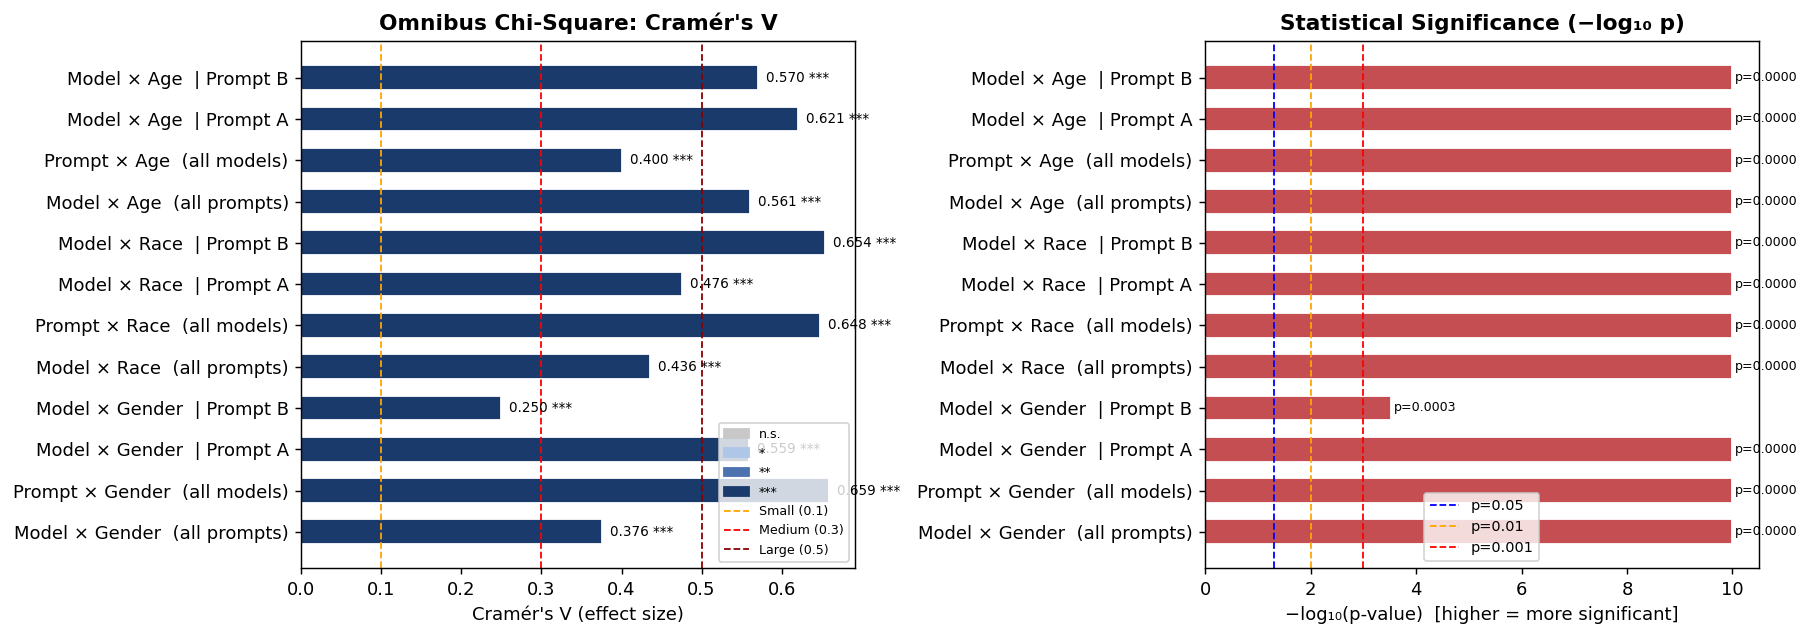

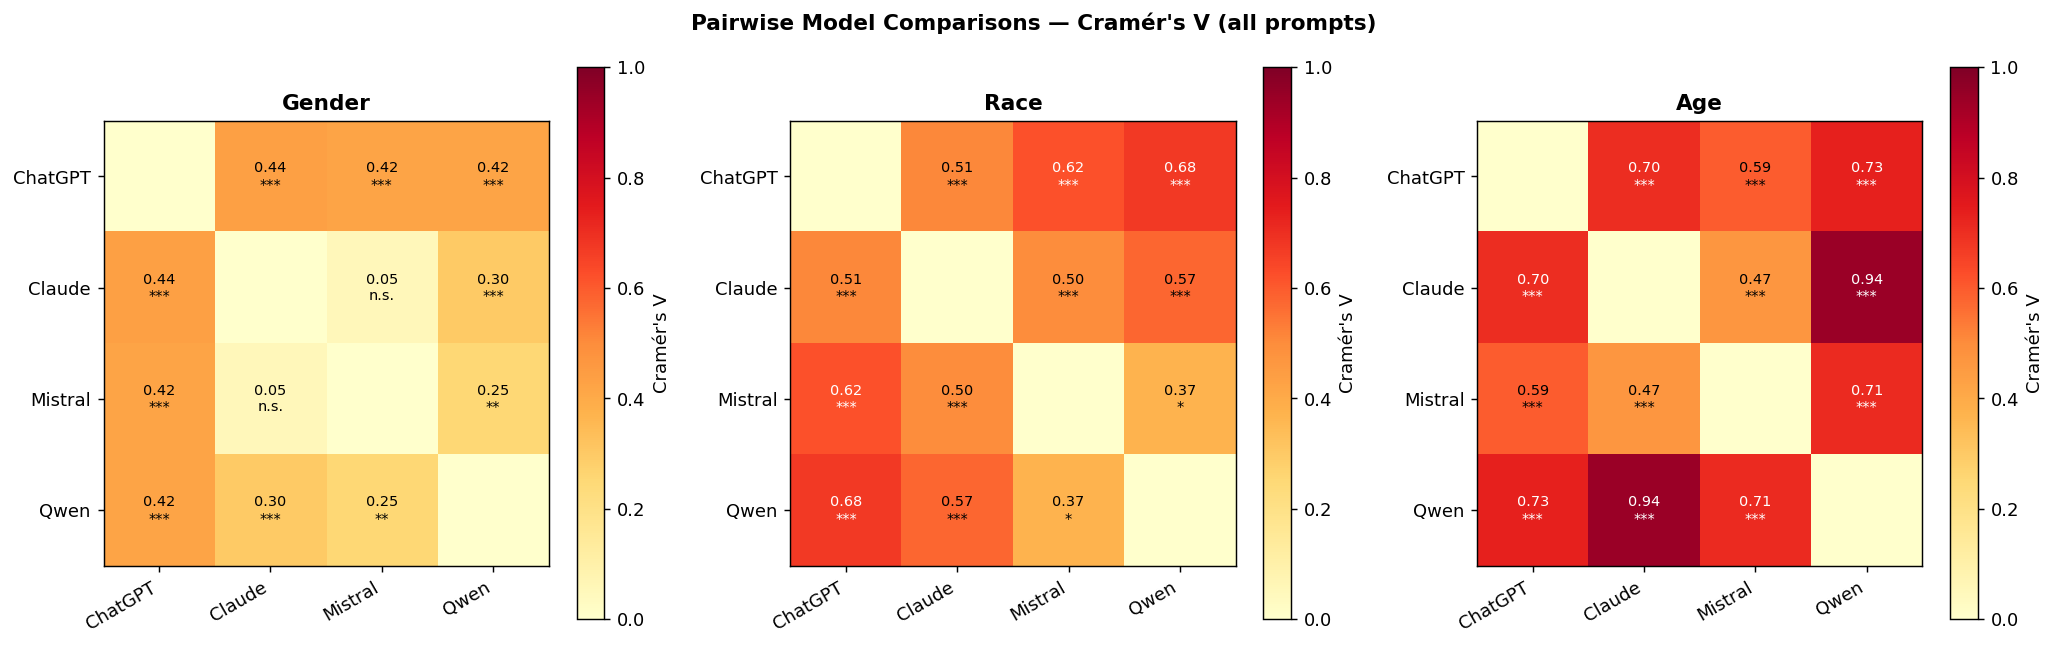

In [18]:
# ── Omnibus result summary bar ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Cramér's V grouped by test
ax = axes[0]
colors = {'n.s.': '#C8C8C8', '*': '#AEC6E8', '**': '#4C72B0', '***': '#1A3A6B'}
bar_colors = [colors[s] for s in summary_df['Sig']]
bars = ax.barh(summary_df.index, summary_df["Cramér's V"],
               color=bar_colors, edgecolor='white', height=0.6)
ax.axvline(0.1, color='orange', linestyle='--', linewidth=1, label='Small (0.1)')
ax.axvline(0.3, color='red',    linestyle='--', linewidth=1, label='Medium (0.3)')
ax.axvline(0.5, color='darkred',linestyle='--', linewidth=1, label='Large (0.5)')
for bar, (_, row) in zip(bars, summary_df.iterrows()):
    v = row["Cramér's V"]
    s = row['Sig']
    ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
            f"{v:.3f} {s}", va='center', fontsize=7.5)
ax.set_xlabel("Cramér's V (effect size)")
ax.set_title("Omnibus Chi-Square: Cramér's V", fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
# colour legend
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
ax.legend(handles=legend_patches + ax.get_legend_handles_labels()[0],
          fontsize=7, loc='lower right')

# Right: p-value heatmap (–log10 scale)
ax2 = axes[1]
log_p = -np.log10(summary_df['p-value'].replace(0, 1e-10))
bar2 = ax2.barh(summary_df.index, log_p,
                color=['#C44E52' if p < 0.001 else '#DD8452' if p < 0.01
                        else '#4C72B0' if p < 0.05 else '#C8C8C8'
                        for p in summary_df['p-value']],
                edgecolor='white', height=0.6)
ax2.axvline(-np.log10(0.05),  color='blue',   linestyle='--', linewidth=1, label='p=0.05')
ax2.axvline(-np.log10(0.01),  color='orange', linestyle='--', linewidth=1, label='p=0.01')
ax2.axvline(-np.log10(0.001), color='red',    linestyle='--', linewidth=1, label='p=0.001')
for bar, (_, row) in zip(bar2, summary_df.iterrows()):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'p={row["p-value"]:.4f}', va='center', fontsize=7)
ax2.set_xlabel('−log₁₀(p-value)  [higher = more significant]')
ax2.set_title('Statistical Significance (−log₁₀ p)', fontweight='bold')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/chi2_omnibus.png', bbox_inches='tight')
plt.show()

# ── Pairwise Cramér's V heatmaps ─────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
fig2.suptitle("Pairwise Model Comparisons — Cramér's V (all prompts)",
              fontsize=12, fontweight='bold')

model_list = sorted(data['model'].unique())
for ax, (attr, col) in zip(axes2, ATTR_COLS.items()):
    mat = pd.DataFrame(np.nan, index=model_list, columns=model_list)
    pmat = pd.DataFrame(np.nan, index=model_list, columns=model_list)
    for m1, m2 in combinations(model_list, 2):
        pair_df = data[data['model'].isin([m1, m2])]
        ct = pd.crosstab(pair_df['model'], pair_df[col])
        ct = ct.loc[(ct > 0).any(axis=1), (ct > 0).any(axis=0)]
        if ct.shape[0] < 2 or ct.shape[1] < 2:
            continue
        chi2, p, dof, _ = chi2_contingency(ct, correction=False)
        n = ct.values.sum()
        v = cramers_v(chi2, n, *ct.shape)
        p_b = min(p * 6, 1.0)
        mat.loc[m1, m2] = v
        mat.loc[m2, m1] = v
        pmat.loc[m1, m2] = p_b
        pmat.loc[m2, m1] = p_b
    for _m in model_list:
        mat.loc[_m, _m] = 0.0

    im = ax.imshow(mat.astype(float).values, cmap='YlOrRd', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label="Cramér's V")
    ax.set_xticks(range(len(model_list)))
    ax.set_yticks(range(len(model_list)))
    ax.set_xticklabels(model_list, rotation=30, ha='right')
    ax.set_yticklabels(model_list)
    ax.set_title(f'{attr}', fontweight='bold')

    for i, m1 in enumerate(model_list):
        for j, m2 in enumerate(model_list):
            v = mat.loc[m1, m2]
            if not np.isnan(v) and i != j:
                p_b = pmat.loc[m1, m2]
                stars = '' if np.isnan(p_b) else sig_stars(p_b)
                text = f'{v:.2f}\n{stars}' if stars else f'{v:.2f}'
                ax.text(j, i, text, ha='center', va='center',
                        fontsize=8, color='white' if v > 0.6 else 'black')

plt.tight_layout()
plt.savefig('figures/chi2_pairwise_heatmap.png', bbox_inches='tight')
plt.show()


### 2A.5 Publication-Ready Summary Table

In [19]:
print('Table 1. Chi-Square Tests of Independence for Demographic Attributes')
print('='*90)
print(f'{"Test":<45} {"χ²":>7} {"df":>4} {"p":>8}  {"Sig":>5}  {"V":>6}  {"Effect":<12} n')
print('-'*90)
for test, row in summary_df.iterrows():
    p_str = '<.001' if row['p-value'] < 0.001 else f"{row['p-value']:.3f}"
    note = f"  {row['Note']}" if row['Note'] else ''
    print(f"{test:<45} {row['χ²']:>7.2f} {row['df']:>4} {p_str:>8}  {row['Sig']:>5}  "
          f"{row["Cramér's V"]:>6.3f}  {row['Effect']:<12} {row['n']}{note}")
print('='*90)
print('Note. Sig: *** p<.001, ** p<.01, * p<.05, n.s. not significant.')
print('      Effect size: Cramér\'s V; Small ≥0.1, Medium ≥0.3, Large ≥0.5.')
print('      ⚠ = >20% of expected cell counts below 5; interpret with caution.')


Table 1. Chi-Square Tests of Independence for Demographic Attributes
Test                                               χ²   df        p    Sig       V  Effect       n
------------------------------------------------------------------------------------------
Model × Gender  (all prompts)                  113.37    6    <.001    ***   0.376  Medium       400
Prompt × Gender  (all models)                  173.93    2    <.001    ***   0.659  Large        400
Model × Gender  | Prompt A                     124.91    6    <.001    ***   0.559  Large        200
Model × Gender  | Prompt B                      24.96    6    <.001    ***   0.250  Small        200  ⚠ low expected
Model × Race  (all prompts)                    200.48   30    <.001    ***   0.436  Medium       351  ⚠ low expected
Prompt × Race  (all models)                    147.47   10    <.001    ***   0.648  Large        351  ⚠ low expected
Model × Race  | Prompt A                       102.65   12    <.001    ***   0.476  Med